# Quickstart: your first water mass transformation

`xwmt` turns ocean model tracer budgets into **water mass transformation** (WMT) rates: the
rate at which surface fluxes and interior mixing convert seawater across a chosen tracer
surface, in Sverdrups ($1\ \text{Sv} = 10^{6}\ \text{m}^{3}\,\text{s}^{-1}$).

### What you'll learn

- How to hand `xwmt` a grid and a budget dictionary, and get a `WaterMassTransformations` object.
- How to ask that object **what it can compute** — which $\lambda$ coordinates and which processes.
- How to choose density bins, and why bin width is a real physical choice rather than a detail.
- How to compute and plot a transformation curve, and **how to read its sign**.

### Prerequisites

Some familiarity with `xarray`. You do *not* need to know `xgcm`, `xbudget`, or MOM6 — this
notebook builds everything it needs from scratch.

**No download, no network, no model output.** This notebook builds a small synthetic basin in
memory and runs end to end in a few seconds.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import xwmt

print("xwmt version", xwmt.__version__)

xwmt version 0.3.0


## An idealized basin

Real WMT calculations start from model output, which means a download and a slow first cell.
To keep this notebook instant and reproducible, we instead build a synthetic North-Atlantic-like
basin from analytic profiles. The helper lives next to this notebook in `synthetic_ocean.py`,
and it contains no `xwmt` machinery at all — it just returns an `xgcm.Grid` and a budget
dictionary, exactly the two things you would build for your own model.

**Be clear about what this is.** These are not model output, and the numbers below are not a
result about the ocean — do not cite them. What *is* real is the **shape** of the answer: the
basin is warm, salty and heated in the subtropics, and cold, fresh and strongly cooled in the
subpolar gyre, so the transformation it produces behaves the way the real thing does.

In [2]:
from synthetic_ocean import make_idealized_basin

grid, budget = make_idealized_basin()
grid._ds

<xarray.Dataset> Size: 2MB
Dimensions:                  (xh: 40, yh: 40, z_l: 30, xq: 41, yq: 41, z_i: 31)
Coordinates:
  * xh                       (xh) float64 320B -59.25 -57.75 ... -2.25 -0.75
  * yh                       (yh) float64 320B 20.62 21.88 23.12 ... 68.12 69.38
  * z_l                      (z_l) float64 240B 2.222 11.11 ... 3.869e+03
  * xq                       (xq) float64 328B -60.0 -58.5 -57.0 ... -1.5 0.0
  * yq                       (yq) float64 328B 20.0 21.25 22.5 ... 68.75 70.0
  * z_i                      (z_i) float64 248B 0.0 4.444 ... 3.738e+03 4e+03
    lon                      (yh, xh) float64 13kB -59.25 -57.75 ... -2.25 -0.75
    lat                      (yh, xh) float64 13kB 20.62 20.62 ... 69.38 69.38
Data variables:
    areacello                (yh, xh) float64 13kB 2.17e+10 ... 8.166e+09
    thkcello                 (z_l, yh, xh) float64 384kB 4.444 4.444 ... 262.2
    thetao                   (z_l, yh, xh) float64 384kB 27.88 27.88 ... 2.0 2.0
    so                       (z_l, yh, xh) float64 384kB 35.58 35.58 ... 34.8
    hfds                     (yh, xh) float64 13kB 99.9 99.9 ... -95.37 -95.37
    wfo                      (yh, xh) float64 13kB -1.629e-05 ... 4.112e-06
    heat_tendency_surface    (z_l, yh, xh) float64 384kB 2.168e+12 ... -0.0
    salt_tendency_surface    (z_l, yh, xh) float64 384kB 1.258e+04 ... -0.0
    heat_tendency_diffusion  (z_l, yh, xh) float64 384kB -4.599e+11 ... 1.965...

Two things to notice. `grid` is a plain `xgcm.Grid`, and the dataset holding the actual fields
hangs off it as `grid._ds` — that is where `xwmt` looks for tracers, thicknesses and tendencies.
And `budget` is just a dictionary: it names which variable plays the role of $\lambda$ for each
budget (`thetao` for heat, `so` for salt) and which variables hold the tendency terms acting on
it. For MOM6 output the `xbudget` package writes this dictionary for you; here it is short
enough to read.

In [3]:
budget

{'mass': {'thickness': 'thkcello'},
 'heat': {'lambda': 'thetao',
  'rhs': {'surface_exchange_flux': 'heat_tendency_surface',
   'diffusion': 'heat_tendency_diffusion'}},
 'salt': {'lambda': 'so',
  'rhs': {'surface_exchange_flux': 'salt_tendency_surface'}}}

## Look at what you built

The generator should not be a black box, so before computing anything, let's confirm this
"ocean" actually looks like an ocean. The fields vary with latitude only — this is an idealized
basin, not a simulation — but the structure that drives the transformation is all here.

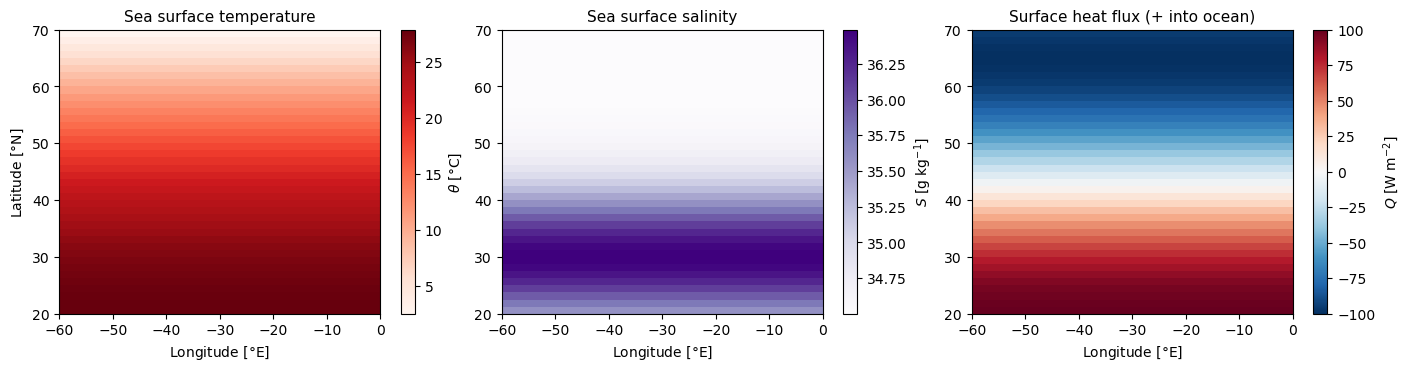

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)

sst = grid._ds.thetao.isel(z_l=0)
sss = grid._ds.so.isel(z_l=0)
hfds = grid._ds.hfds

# Magnitude -> sequential, one hue. Polarity -> diverging, centred on zero.
for ax, field, cmap, kw, title, label in [
    (axes[0], sst, "Reds", {}, "Sea surface temperature", r"$\theta$ [$\degree$C]"),
    (axes[1], sss, "Purples", {}, "Sea surface salinity", r"$S$ [g kg$^{-1}$]"),
    (axes[2], hfds, "RdBu_r", {"vmin": -100, "vmax": 100},
     "Surface heat flux (+ into ocean)", r"$Q$ [W m$^{-2}$]"),
]:
    m = ax.pcolormesh(field.xh, field.yh, field, cmap=cmap, shading="auto", **kw)
    fig.colorbar(m, ax=ax, label=label)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(r"Longitude [$\degree$E]")
axes[0].set_ylabel(r"Latitude [$\degree$N]")
plt.show()

That is the story in three panels: a warm, salty subtropical gyre that the atmosphere is
*heating* (red, positive $Q$), and a cold, fresher subpolar gyre that the atmosphere is
*cooling* hard (blue, negative $Q$). Everything below is a consequence of those two facts.

## What can I ask for?

Create the core object by handing it the grid and the budget dictionary.

In [5]:
wmt = xwmt.WaterMassTransformations(grid, budget)

Two discovery methods answer "what can this object actually compute?", and they are the first
things worth calling on any new dataset.

`lambdas()` lists the **coordinates you can bin in** — the tracer surfaces across which
transformation can be measured. Note that `thetao` and `so` come straight from the budget
dictionary, while the `sigma` entries are *derived*: `xwmt` will call the equation of state on
temperature and salinity for you, so potential density is available even though nothing in
`grid._ds` is named `sigma0`.

In [6]:
wmt.lambdas()

['thetao', 'so', 'sigma0', 'sigma1', 'sigma2', 'sigma3', 'sigma4']

`available_processes()` lists the **physical processes** it found — the right-hand-side terms
from the budget dictionary that are actually present in the data. Our basin has two: surface
fluxes of heat and freshwater, and interior vertical diffusion of heat. A real MOM6 budget will
return a much longer list.

In [7]:
sorted(wmt.available_processes())

['diffusion', 'surface_exchange_flux']

## Choosing bins

Transformation is always reported *per bin* of the $\lambda$ coordinate, so you need bin edges
before you can compute anything. If you have no idea what range your density spans, `infer_bins`
will look at the data and pick for you. Give it the field to bin and `nbins`, the number of edges
to spread across that field's range.

It also takes `percentiles`, which clips the range before spreading the edges — `[0.01, 0.99]`
spans the 1st to 99th percentile instead of the full min-to-max, so a handful of outlier cells
can't stretch the axis and waste bins on density classes that hold almost no water.

In [8]:
sigma0 = wmt.get_density("sigma0")

print("full range:", np.round(wmt.infer_bins(sigma0, nbins=21), 2))
print("1st-99th:  ", np.round(wmt.infer_bins(sigma0, percentiles=[0.01, 0.99], nbins=21), 2))

full range: [22.74 23.   23.25 23.5  23.75 24.   24.26 24.51 24.76 25.01 25.26 25.51
 25.77 26.02 26.27 26.52 26.77 27.03 27.28 27.53 27.78]
1st-99th:   [23.49 23.71 23.92 24.14 24.35 24.56 24.78 24.99 25.2  25.42 25.63 25.85
 26.06 26.27 26.49 26.7  26.91 27.13 27.34 27.56 27.77]


So this basin spans roughly $\sigma_0 = 22.7$ to $27.8$ kg m$^{-3}$, and 21 edges across that
range gives bins about 0.25 kg m$^{-3}$ wide. Trimming to the 1st–99th percentile pulls the light
end in to about 23.5: the very lightest water is a thin sliver of the warmest surface subtropics,
so it moves the edge noticeably while representing very little mass.

For the real calculation we'll use round explicit bins of that same ~0.25 width, both because
they are reproducible and because **the width is a physical choice, not a cosmetic one**.

It is worth being blunt about why. Transformation is a *derivative* — a flux divergence in
density space — so it is estimated by differencing across bin edges. If you make the bins much
narrower than the density contrast between neighbouring grid cells, most bins catch only a
handful of cells and the estimate degenerates. This basin is small (40 × 40 × 30, and its fields
vary with latitude only), so it is easy to out-resolve: narrowing the bins to 0.05 nearly
*triples* the peak of the curve below. That growth is undersampling, not physics — a peak that
keeps climbing as you narrow the bins is a warning, not a sharper answer.

Even at 0.25 the curve below stays somewhat ragged, which is this basin being coarse rather than
anything going wrong; a real model with more cells fills its bins far better and supports
narrower ones. The habit to take away: **vary the bin width and confirm your answer is not
sensitive to it** before believing any transformation curve, including this one.

## Compute the transformation

`integrate_transformations` does the work: it bins every tendency term into $\lambda$ space and
integrates over the basin. `sum_components=True` adds up the heat and salt contributions within
each process.

In [9]:
bins = np.arange(20.0, 28.5, 0.25)
G = wmt.integrate_transformations("sigma0", bins=bins, sum_components=True)
G

<xarray.Dataset> Size: 2kB
Dimensions:                     (sigma0_l_target: 33)
Coordinates:
  * sigma0_l_target             (sigma0_l_target) float64 264B 20.12 ... 28.12
Data variables:
    diffusion_heat              (sigma0_l_target) float64 264B -0.0 ... -0.0
    surface_exchange_flux_heat  (sigma0_l_target) float64 264B -0.0 ... -0.0
    surface_exchange_flux_salt  (sigma0_l_target) float64 264B -0.0 ... -0.0
    diffusion                   (sigma0_l_target) float64 264B 0.0 0.0 ... 0.0
    surface_exchange_flux       (sigma0_l_target) float64 264B 0.0 0.0 ... 0.0

The result holds **both** the per-component terms (`diffusion_heat`,
`surface_exchange_flux_heat`, `surface_exchange_flux_salt`) **and** the per-process sums
(`diffusion`, `surface_exchange_flux`). The total transformation is the sum of the two
*processes* only — summing every variable in the dataset would double-count the components.

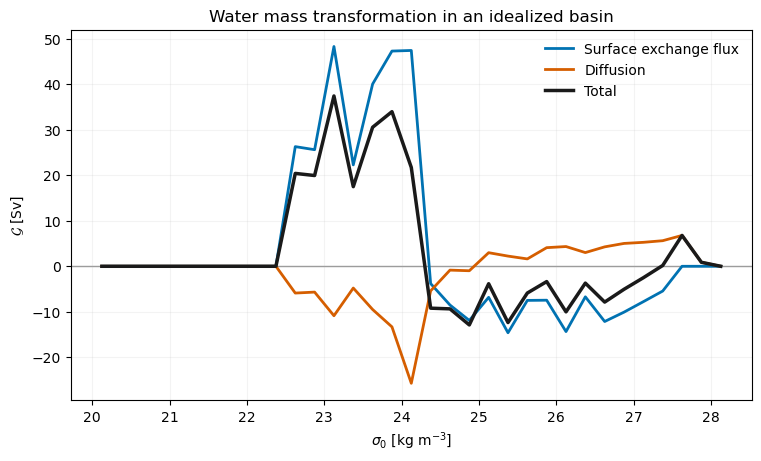

peak +37.4 Sv at sigma0 = 23.12
min  -12.9 Sv at sigma0 = 24.88


In [10]:
Sv = 1e-6 / 1035.0  # kg s^-1 -> Sv, dividing by a reference density

surface = G["surface_exchange_flux"] * Sv
diffusion = G["diffusion"] * Sv
total = surface + diffusion

fig, ax = plt.subplots(figsize=(7.5, 4.5), constrained_layout=True)
x = G.sigma0_l_target

ax.axhline(0, color="0.6", lw=1, zorder=1)
ax.plot(x, surface, color="#0072B2", lw=2, label="Surface exchange flux")
ax.plot(x, diffusion, color="#D55E00", lw=2, label="Diffusion")
ax.plot(x, total, color="#1A1A1A", lw=2.5, label="Total", zorder=3)

ax.set_xlabel(r"$\sigma_0$ [kg m$^{-3}$]")
ax.set_ylabel(r"$\mathcal{G}$ [Sv]")
ax.set_title("Water mass transformation in an idealized basin")
ax.legend(frameon=False)
ax.grid(True, alpha=0.15)
plt.show()

print(f"peak {float(total.max()):+.1f} Sv at sigma0 = {float(total.idxmax()):.2f}")
print(f"min  {float(total.min()):+.1f} Sv at sigma0 = {float(total.idxmin()):.2f}")

## Reading the sign

This is the one convention you must internalize, because every number above depends on it.

> In `xwmt`, water mass transformations are defined such that they are **positive when they tend
> to increase the mass of water with tracer values less than the given threshold**
> $\tilde{\lambda}$.

With $\lambda = \sigma_0$, "less than the threshold" means *lighter than*. So:

- **Positive $\mathcal{G}$ = lightening** — water is being converted toward lower density.
- **Negative $\mathcal{G}$ = densification** — water is being converted toward higher density.

The curve is a dipole, and each lobe is one of the two panels you plotted earlier. The peak of
about $+37$ Sv near $\sigma_0 = 23.1$ is the **subtropics**: the atmosphere heats warm, light
water, making it lighter still, which increases the mass of water lighter than that threshold —
positive. The trough of about $-13$ Sv near $\sigma_0 = 24.9$ is the **subpolar gyre**: strong
cooling densifies water, decreasing the mass lighter than that threshold — negative. That
negative lobe is the idealized ancestor of the transformation that feeds deep water formation in
the real North Atlantic.

Note also that the two processes do different jobs, and that **diffusion consistently opposes the
surface forcing**. Surface fluxes set the broad shape of both lobes. Diffusion then works against
them at each end: it is negative (densifying) right where surface heating is most strongly
lightening water near $\sigma_0 \approx 24$, and positive (lightening) at the dense end where
surface cooling is densifying. That is mixing doing what mixing does — eroding the extremes the
boundary fluxes create, rather than reinforcing them.

## Where next

- **`closed_transformation_budget.ipynb`** — the same calculation on real MOM6 output, with a
  full budget from `xbudget` and a check that the transformation budget actually closes.
- **`north_atlantic_deep_water.ipynb`** — a case study that takes the negative lobe above
  seriously and uses it to quantify deep water formation.
- **`bring_your_own_model.ipynb`** — start here if you are not running MOM6; it covers writing
  the budget dictionary and building the `xgcm.Grid` for your own output.